# Tube Marks - Right Side (cam151)
Manual/bootstrap workflow for right-side images (`cam151`) in the new clean repo.
This notebook is the clean replacement for the legacy manual notebook, but it starts with the lighter `cam151_ref_detection` bootstrap pipeline.


## Workflow (cam151) - Bootstrap

This notebook currently does:
1. load a new `cam151` image
2. run the clean bootstrap pipeline
3. inspect green structures
4. inspect the bottom ROI
5. inspect line candidates
6. read the generated `summary.json`

It does **not** yet reproduce the full legacy notebook pipeline with SAM2, manual marks and top-down geometry.
This notebook is the starting point to build that flow again in a cleaner way for `cam151`.


In [51]:
from pathlib import Path
import json
import sys

import cv2
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cam151_ref_detection import Cam151Config, run_cam151_bootstrap


In [52]:
# [02] Paths
TEST_IMAGES_DIR = ROOT / "test_images"
IMG_PATHS = sorted(TEST_IMAGES_DIR.glob("cam151_wide_*.jpg"))
if not IMG_PATHS:
    raise RuntimeError(f"No cam151 images found in {TEST_IMAGES_DIR}")

for idx, path in enumerate(IMG_PATHS):
    print(f"[{idx}] {path.name}")


[0] cam151_wide_20260323_100046.jpg
[1] cam151_wide_20260323_102005.jpg
[2] cam151_wide_20260323_103026.jpg
[3] cam151_wide_20260323_120028.jpg
[4] cam151_wide_20260323_140058.jpg


In [53]:
# [03] Select image + config
IMG_INDEX = 3
IMG_PATH = IMG_PATHS[IMG_INDEX]
OUT_DIR = ROOT / "artifacts" / IMG_PATH.stem
CFG = Cam151Config()

print("ROOT:", ROOT)
print("IMG_PATH:", IMG_PATH)
print("OUT_DIR:", OUT_DIR)


ROOT: c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean
IMG_PATH: c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\test_images\cam151_wide_20260323_120028.jpg
OUT_DIR: c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\cam151_wide_20260323_120028


In [54]:
# [04] Run bootstrap pipeline
summary = run_cam151_bootstrap(IMG_PATH, OUT_DIR, CFG)
summary


{'image_path': 'c:\\Users\\luis_\\Downloads\\descarga_imagenes\\cam151_ref_detection_clean\\test_images\\cam151_wide_20260323_120028.jpg',
 'image_shape': [1536, 2048, 3],
 'config': {'green_h_lo': 35,
  'green_s_lo': 35,
  'green_v_lo': 35,
  'green_h_hi': 95,
  'green_s_hi': 255,
  'green_v_hi': 255,
  'green_open_size': 5,
  'green_close_size': 11,
  'min_green_area': 1500,
  'bottom_roi_y_frac': 0.66,
  'canny_low': 40,
  'canny_high': 120,
  'hough_threshold': 55,
  'hough_min_line_length': 120,
  'hough_max_line_gap': 20},
 'green_components': [{'label': 3,
   'bbox': [0, 1499, 811, 1536],
   'area': 28887,
   'centroid': [396.21321009450617, 1517.5905770761935],
   'aspect': 0.04562268803945746,
   'orientation': 'horizontal'},
  {'label': 2,
   'bbox': [45, 201, 374, 703],
   'area': 20302,
   'centroid': [212.42227366761895, 451.7609102551473],
   'aspect': 1.5258358662613982,
   'orientation': 'vertical'},
  {'label': 1,
   'bbox': [876, 179, 1004, 683],
   'area': 18103,
   

In [55]:
# [05] Helper to show BGR images
def show_bgr(path: Path, title: str, figsize=(14, 7)):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


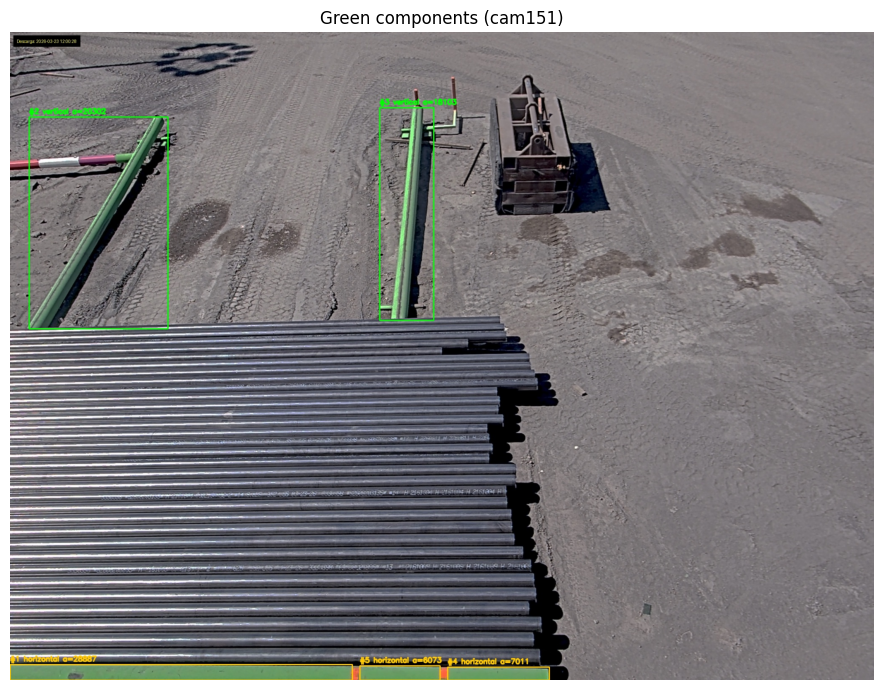

In [56]:
# [06] Green structures
show_bgr(OUT_DIR / "02_green_components.jpg", "Green components (cam151)")


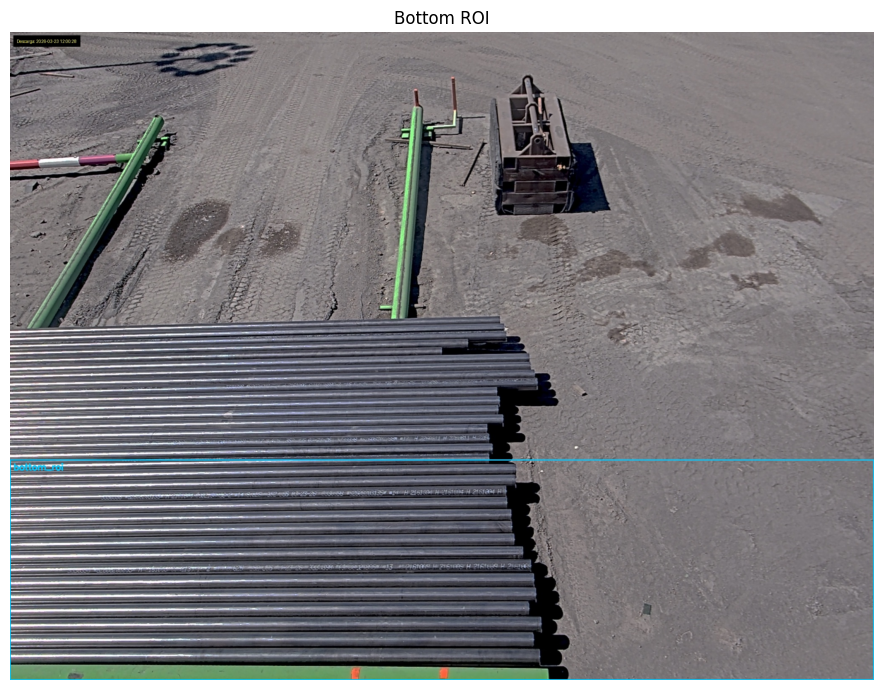

In [57]:
# [07] Bottom ROI
show_bgr(OUT_DIR / "03_bottom_roi.jpg", "Bottom ROI")


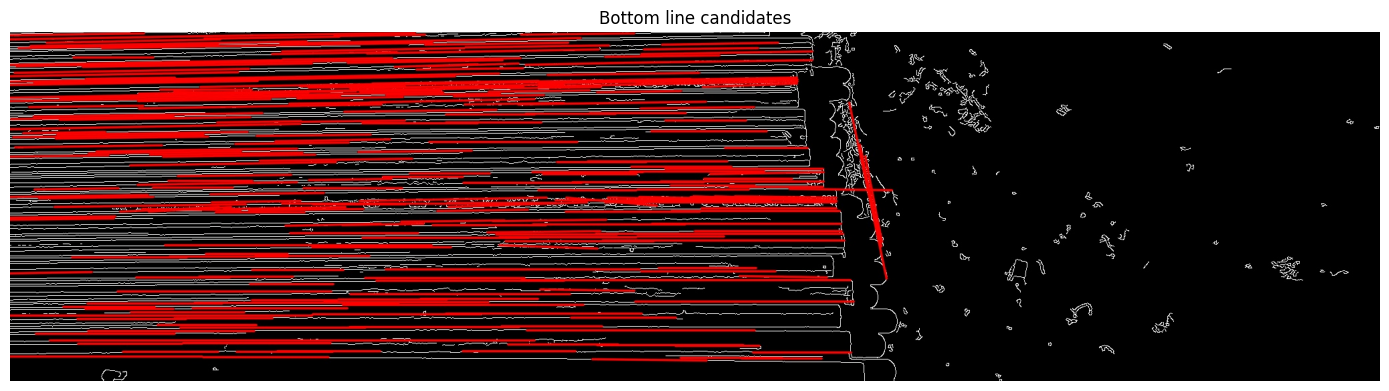

In [58]:
# [08] Bottom line candidates
show_bgr(OUT_DIR / "05_bottom_lines.jpg", "Bottom line candidates")


In [59]:
# [09] Read summary JSON
summary_path = OUT_DIR / "summary.json"
summary_data = json.loads(summary_path.read_text(encoding="utf-8"))
summary_data


{'image_path': 'c:\\Users\\luis_\\Downloads\\descarga_imagenes\\cam151_ref_detection_clean\\test_images\\cam151_wide_20260323_120028.jpg',
 'image_shape': [1536, 2048, 3],
 'config': {'green_h_lo': 35,
  'green_s_lo': 35,
  'green_v_lo': 35,
  'green_h_hi': 95,
  'green_s_hi': 255,
  'green_v_hi': 255,
  'green_open_size': 5,
  'green_close_size': 11,
  'min_green_area': 1500,
  'bottom_roi_y_frac': 0.66,
  'canny_low': 40,
  'canny_high': 120,
  'hough_threshold': 55,
  'hough_min_line_length': 120,
  'hough_max_line_gap': 20},
 'green_components': [{'label': 3,
   'bbox': [0, 1499, 811, 1536],
   'area': 28887,
   'centroid': [396.21321009450617, 1517.5905770761935],
   'aspect': 0.04562268803945746,
   'orientation': 'horizontal'},
  {'label': 2,
   'bbox': [45, 201, 374, 703],
   'area': 20302,
   'centroid': [212.42227366761895, 451.7609102551473],
   'aspect': 1.5258358662613982,
   'orientation': 'vertical'},
  {'label': 1,
   'bbox': [876, 179, 1004, 683],
   'area': 18103,
   

In [60]:
# [10] Quick inspection
print("Green components:", len(summary_data["green_components"]))
for idx, comp in enumerate(summary_data["green_components"], start=1):
    print(idx, comp)

print("\nTop 10 bottom lines:")
for idx, line in enumerate(summary_data["bottom_lines"][:10], start=1):
    print(idx, line)


Green components: 5
1 {'label': 3, 'bbox': [0, 1499, 811, 1536], 'area': 28887, 'centroid': [396.21321009450617, 1517.5905770761935], 'aspect': 0.04562268803945746, 'orientation': 'horizontal'}
2 {'label': 2, 'bbox': [45, 201, 374, 703], 'area': 20302, 'centroid': [212.42227366761895, 451.7609102551473], 'aspect': 1.5258358662613982, 'orientation': 'vertical'}
3 {'label': 1, 'bbox': [876, 179, 1004, 683], 'area': 18103, 'centroid': [942.7686018891897, 441.50919737060156], 'aspect': 3.9375, 'orientation': 'vertical'}
4 {'label': 5, 'bbox': [1037, 1505, 1278, 1536], 'area': 7011, 'centroid': [1156.2973898160035, 1520.77891884182], 'aspect': 0.12863070539419086, 'orientation': 'horizontal'}
5 {'label': 4, 'bbox': [829, 1502, 1019, 1536], 'area': 6073, 'centroid': [922.4488720566442, 1519.3329491190516], 'aspect': 0.17894736842105263, 'orientation': 'horizontal'}

Top 10 bottom lines:
1 {'p1': [433, 82], 'p2': [1176, 69], 'length': 743.113719426576, 'angle_deg': -1.0023810775103177}
2 {'p1

In [61]:
# [11] Tuning cell
# Use this cell to iterate faster on thresholds without touching the package defaults.
CFG_TUNED = Cam151Config(
    min_green_area=1000,
    bottom_roi_y_frac=0.62,
    hough_threshold=45,
    hough_min_line_length=100,
)

# summary_tuned = run_cam151_bootstrap(IMG_PATH, ROOT / "artifacts" / f"{IMG_PATH.stem}_tuned", CFG_TUNED)
# summary_tuned
